# About this notebook

This notebook serves for developing a finetuning a series of functions for annotating paratext (titles, headers, footers and margins) in the texblocks data from the PDFs.

This functions are subsequently used within an interactive `streamlit` app which iterates through all the PDFs.

In [1]:
import fitz
import requests
import io
import pickle
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
from bs4 import BeautifulSoup
import pandas as pd
import nltk
import random

In [3]:
test_filename = "100085_Libavius1606_Commentariorum_alchemiae_pars_1_MDZ_MBS.pdf"
doc = fitz.open(os.path.join("/srv/data/tome/tome-corpus/EMLAP_2025-10-31/pdfs_only/", test_filename))

In [4]:
doc.page_count

413

In [5]:
p = doc.load_page(14)

In [6]:
p

page 14 of /srv/data/tome/tome-corpus/EMLAP_2025-10-31/pdfs_only/100085_Libavius1606_Commentariorum_alchemiae_pars_1_MDZ_MBS.pdf

In [7]:
pix = p.get_pixmap()

In [8]:
pix.width

2232

In [9]:
pix.height

3968

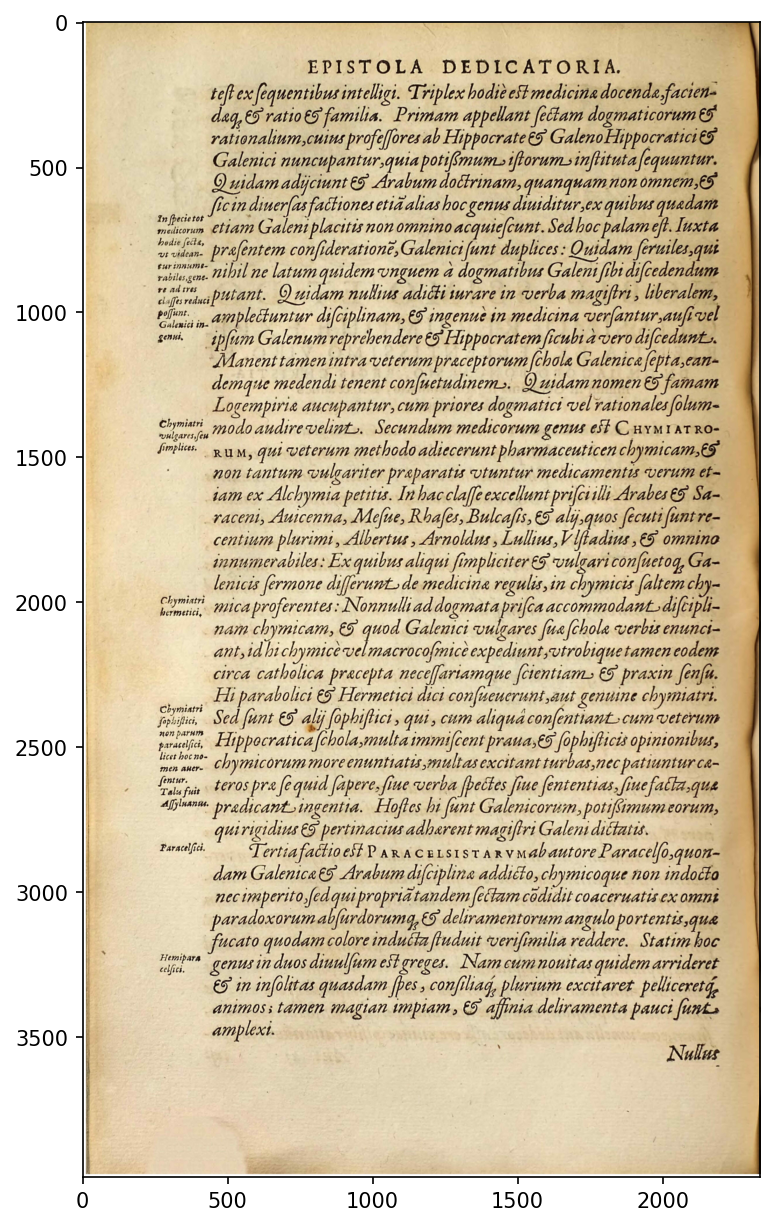

In [16]:
p = doc.load_page(4)
pix = p.get_pixmap()
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.imshow(np_array)
plt.show()

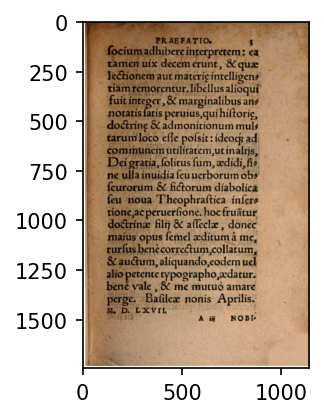

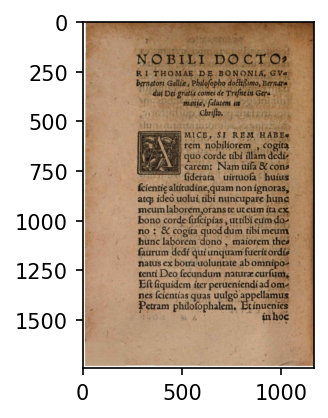

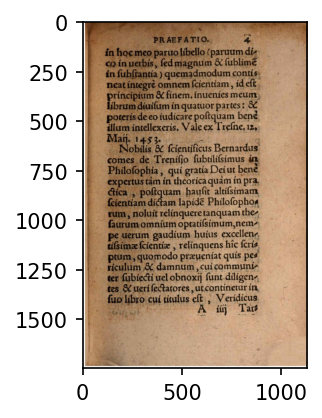

In [10]:
for p in [p for p in doc][5:8]:
    pix = p.get_pixmap()
    np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    ax.imshow(np_array)
    plt.show()

In [11]:
print(p.get_text())

PRAEFATIO. 4
in hoc meo paruo libello (paruum di¬
co in uerbis, sed magnum & sublimen
in substantia) quemadmodum conti¬
neat integre omnem scientiam, id est
principium & finem, inuenies meum
librum diuisum in quatuor partes: &
poteris de eo iudicare postquam benè
illum intellexeris. Vale ex Tresne. 12.
Maij. 1453.
Nobilis & scientificus Bernardus
comes de Trenisio subtilissimus in
Philosophia, qui gratia Dei ut bene
expertus tàm in theorica quàm in pra¬
ctica, postquam hausit altissimam
scientiam dictam lapidem Philosopho¬
rum, noluit relinquere tanquam the¬
saurum omnium optatissimum, nem¬
pe uerum gaudium huius excellen¬
tissimae scientiae, relinquens hîc scri¬
ptum, quomodo praeueniat quis pe¬
riculum & damnum, cui communi¬
ter subiecti uel obnoxij sunt diligen¬
tes & ueri sectatores, ut continetur in
suo libro cui titulus est, Veridicus
A iiij Tar¬



In [12]:
textblocks = p.get_text_blocks() # ("blocks")
textblocks

[(350.8800048828125,
  102.96005249023438,
  857.8248901367188,
  107.76004791259766,
  'PRAEFATIO. 4\n',
  0,
  0),
 (102.4800033569336,
  167.76010131835938,
  878.9548950195312,
  172.5601043701172,
  'in hoc meo paruo libello (paruum di¬\n',
  1,
  0),
 (105.36000061035156,
  221.54409790039062,
  886.8265380859375,
  226.46409606933594,
  'co in uerbis, sed magnum & sublimen\n',
  2,
  0),
 (112.08000183105469,
  274.5840148925781,
  888.4375,
  279.5040283203125,
  'in substantia) quemadmodum conti¬\n',
  3,
  0),
 (115.91999816894531,
  329.0400085449219,
  884.2129516601562,
  333.8399963378906,
  'neat integre omnem scientiam, id est\n',
  4,
  0),
 (121.68000030517578,
  383.2799987792969,
  895.36767578125,
  388.0799865722656,
  'principium & finem, inuenies meum\n',
  5,
  0),
 (122.63999938964844,
  436.5840148925781,
  889.7797241210938,
  441.5040283203125,
  'librum diuisum in quatuor partes: &\n',
  6,
  0),
 (133.1999969482422,
  491.0400085449219,
  892.3779296875,


In [13]:
central_textblocks = textblocks[2:-1]
len(central_textblocks)

23

In [14]:
len(textblocks)

26

In [15]:
central_textblocks = textblocks[2:-1]
avg_width = np.mean([rect[2] - rect[0] for rect in central_textblocks])
avg_left_x = np.mean([rect[0] for rect in central_textblocks])
avg_right_x = np.mean([rect[2] for rect in central_textblocks])

avg_charn = sum([len(textblock) for textblock in central_textblocks]) / len(central_textblocks)
avg_charn_density = avg_charn / avg_width

In [16]:
def check_header(textblock, avg_width, avg_left_x, header_width_proportion_max=0.8, header_left_x_ratio_min=1.2, header_uppercase_proportion_min = 0.6, header_digits_proportion_min = 0.6):
    width_ratio = (textblock[2] - textblock[0])  / avg_width # thinner than average line
    left_x_ratio = textblock[0] / avg_left_x # more right than average line
    textblock_text = textblock[4].replace("\n", "")
    uppercase_ratio = sum(1 for char in textblock_text if char.isupper()) / len(textblock_text)
    digits_ratio =  sum(1 for char in textblock_text if char.isdigit()) / len(textblock_text)
    if sum([(width_ratio < header_width_proportion_max),(left_x_ratio > header_left_x_ratio_min),(uppercase_ratio > header_uppercase_proportion_min),(digits_ratio > header_digits_proportion_min)]) >= 2: # if first
        return True
    else:
        return False
def check_footer(textblock, avg_width, avg_left_x, avg_right_x, footer_width_proportion_max=0.5, footer_left_x_ratio_min=1.2):
    width_ratio = (textblock[2] - textblock[0])  / avg_width # thinner than average line
    left_x_ratio = textblock[0] / avg_left_x # more right than average line
    right_x_ratio = textblock[2] / avg_right_x # more right than average line
    textblock_text = textblock[4].replace("\n", "")
    digits_ratio =  sum(1 for char in textblock_text if char.isdigit()) / len(textblock_text)
    if sum([(width_ratio < footer_width_proportion_max), (left_x_ratio > 1.2),  (0.9 < right_x_ratio < 1.1),(digits_ratio > 0.6)]) >= 2: # if first
        return True
    else:
        return False

def check_title(textblock, avg_charn_density, textblock_char_density_ratio_max=0.75):
    textblock_char_density = len(textblock[4]) / (textblock[2] - textblock[0])
    textblock_char_density_ratio = textblock_char_density / avg_charn_density
    if textblock_char_density_ratio < textblock_char_density_ratio_max:
        return True
    else:
        return False


In [17]:
patch_color_dict = {"title" : "green",
                    "header" : "red",
                    "footer" : "orange",
                    "margin" : "yellow",
                     "text" : "white",
}

def plot_patch(textblock_annotated, patch_color_dict, ax):
   color = patch_color_dict[textblock_annotated[5]]
   patch = patches.Rectangle((textblock_annotated[0], textblock_annotated[1]),  # Bottom left corner
                              textblock_annotated[2] - textblock_annotated[0],  # Width
                              textblock_annotated[3] - textblock_annotated[1],  # Height
                              linewidth=0.3, edgecolor=color, facecolor='none')
   ax.add_patch(patch) # draw candidate textblocks in black


params = {"header_width_proportion_max" : 0.8,
          "header_left_x_ratio_min" : 1.2,
          "header_uppercase_proportion_min" : 0.6,
          "header_digits_proportion_min" : 0.6,
          "footer_width_proportion_max" : 0.5,
          "footer_left_x_ratio_min" : 1.2,
          "textblock_char_density_ratio_max" : 0.75}

def get_page_annots(textblocks, ax,
                    patch_color_dict=patch_color_dict,
                    params=params):
    textblocks_enumerated = [[el[0], el[1], el[2], el[3], el[4], n] for n, el in enumerate(textblocks)]
    textblocks = sorted(textblocks_enumerated, key=lambda x: x[1])
    textblocks = [[el[0], el[1], el[2], el[3], el[4], el[5], n] for n, el in enumerate(textblocks)]
    central_textblocks = textblocks[2:-1]
    avg_width = np.mean([rect[2] - rect[0] for rect in central_textblocks])
    avg_left_x = np.mean([rect[0] for rect in central_textblocks])
    avg_right_x = np.mean([rect[2] for rect in central_textblocks])
    try:
        avg_charn = sum([len(textblock[4]) for textblock in central_textblocks]) / len(central_textblocks)
        avg_charn_density = avg_charn / avg_width
    except:
        avg_charn_density = 0
    textblocks_annotated = []
    for textblock in textblocks:
        annot = "text"
        if textblock[6] in [0,1]:
            if check_header(textblock,
                            avg_width,
                            avg_left_x,
                            header_width_proportion_max=params["header_width_proportion_max"],
                            header_left_x_ratio_min=params["header_left_x_ratio_min"],
                            header_uppercase_proportion_min=params["header_uppercase_proportion_min"],
                            header_digits_proportion_min=params["header_digits_proportion_min"]):
                annot = "header"
        if textblock[6] == len(textblocks) -1:
            if check_footer(textblock,
                            avg_width,
                            avg_left_x,
                            avg_right_x,
                            footer_width_proportion_max=params["footer_width_proportion_max"],
                            footer_left_x_ratio_min=params["footer_left_x_ratio_min"]):
                annot = "footer"
        if annot != "header" and annot != "footer":
            if check_title(textblock,
                           avg_charn_density,
                           textblock_char_density_ratio_max=params["textblock_char_density_ratio_max"]):
                annot = "title"
        textblocks_annotated.append([textblock[0], textblock[1], textblock[2], textblock[3], textblock[4], textblock[5], textblock[6], annot])
    textblocks_annotated_reordered = [[el[0], el[1], el[2], el[3], el[4], el[7]] for el in sorted(textblocks_annotated, key=lambda x: x[5])]
    # marginalia to full annotations
    margin_in_progress = False
    for textblock in textblocks_annotated_reordered:
        if "[M]" in textblock[4]:  # Check for the opening marginalia tag
            textblock[4] = textblock[4].replace("[M]", "")  # Remove the tag
            margin_in_progress = True  # Marginalia started

        if margin_in_progress:  # If within a marginalia block
            textblock[5] = "margin"  # Annotate as margin

        if "[/M]" in textblock[4]:  # Check for the closing marginalia tag
            textblock[4] = textblock[4].replace("[/M]", "")  # Remove the tag
            margin_in_progress = False  # Marginalia ended
        plot_patch(textblock, patch_color_dict, ax)
    return textblocks_annotated_reordered

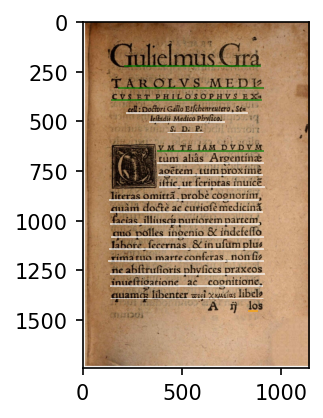

In [18]:
p = doc.load_page(3)
pix = p.get_pixmap()
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
textblocks = p.get_text_blocks()
params = {"header_width_proportion_max" : 0.8,
          "header_left_x_ratio_min" : 1.2,
          "header_uppercase_proportion_min" : 0.6,
          "header_digits_proportion_min" : 0.6,
          "footer_width_proportion_max" : 0.5,
          "footer_left_x_ratio_min" : 1.2,
          "textblock_char_density_ratio_max" : 0.75}
page_textblocks_annotated = get_page_annots(textblocks,
                    ax,
                    patch_color_dict=patch_color_dict,
                    params=params)
ax.imshow(np_array)
plt.show()

In [19]:
page_textblocks_annotated

[[209.0399932861328,
  215.27999877929688,
  894.053955078125,
  220.0800018310547,
  'Gulielmus Gra¬\n',
  'title'],
 [175.44000244140625,
  326.9039611816406,
  910.0022583007812,
  331.823974609375,
  'TAROLVS MEDI¬\n',
  'title'],
 [143.75999450683594,
  388.5600280761719,
  899.9873657226562,
  393.3600158691406,
  'CVS ET PHILOSOPHVS EX¬\n',
  'title'],
 [215.75999450683594,
  452.3999938964844,
  825.4468994140625,
  457.1999816894531,
  'cell: Doctori Gallo Etschenreutero, Se¬\n',
  'text'],
 [331.67999267578125,
  499.6800231933594,
  710.8863525390625,
  504.4800109863281,
  'lestadij Medico Physico.\n',
  'text'],
 [425.5199890136719,
  551.2799682617188,
  603.81201171875,
  556.0800170898438,
  'S. D. P.\n',
  'text'],
 [372.9599914550781,
  644.6640014648438,
  909.0391845703125,
  649.583984375,
  'CVM TE IAM DVDVM\n',
  'title'],
 [372.0,
  703.1998901367188,
  909.5879516601562,
  707.9999389648438,
  'tum aliâs Argentinae\n',
  'text'],
 [378.7200012207031,
  765.3599

In [20]:
# random sample of 8 pages from the doc
random.seed(0)
pages_sample = random.sample([p for p in doc], min(8, len(doc)))

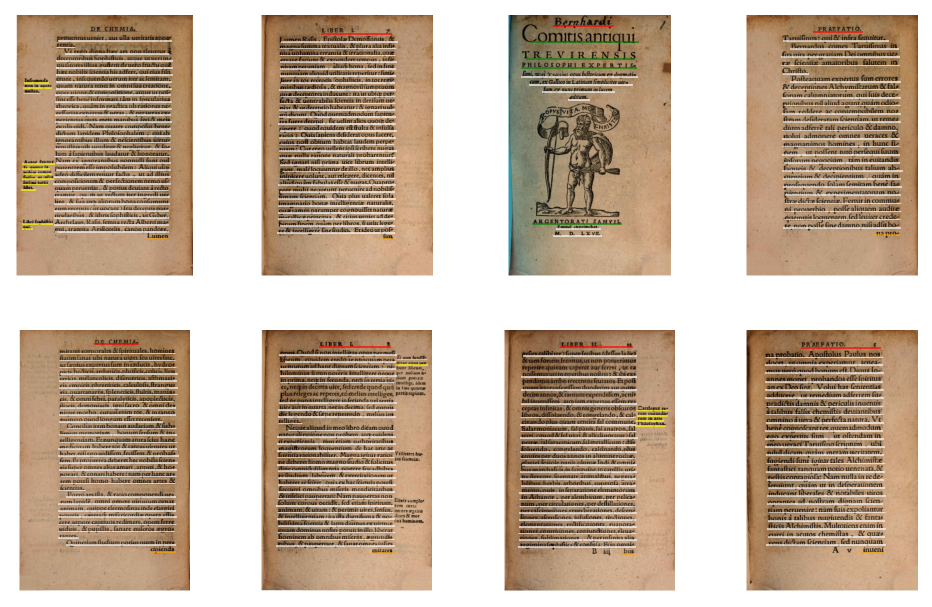

In [21]:
random.seed(0)
pages_sample = random.sample([p for p in doc], min(8, len(doc)))
pages_textblocks_annotated = []
fig, axs = plt.subplots(2,4, figsize=(8, 5), dpi=150)
for p, ax in zip(pages_sample, axs.ravel()):
        pix = p.get_pixmap()
        np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
        textblocks = p.get_text_blocks()
        pages_textblocks_annotated.append(get_page_annots(textblocks,
                    ax, patch_color_dict, params=params))
        ax.axis('off')
        ax.imshow(np_array)

In [ ]:
params = {"header_width_proportion_max" : 0.8,
          "header_left_x_ratio_min" : 1.2,
          "header_uppercase_proportion_min" : 0.6,
          "header_digits_proportion_min" : 0.6,
          "footer_width_proportion_max" : 0.5,
          "footer_left_x_ratio_min" : 1.2,
          "textblock_char_density_ratio_max" : 0.75}
test_doc_annotations(doc, params)

In [ ]:
source_dir = "/srv/data/tome/tome-corpus/emlap_raw_2025-03-10/"
os.listdir(source_dir)

In [32]:
def test_doc_annotations(doc,params):
    random.seed(0)
    pages_sample = random.sample([p for p in doc], min(8, len(doc)))
    pages_textblocks_annotated = []
    fig, axs = plt.subplots(2,4, figsize=(8, 5), dpi=150)
    for p, ax in zip(pages_sample, axs.ravel()):
        pix = p.get_pixmap()
        np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
        textblocks = p.get_text_blocks()
        pages_textblocks_annotated.append(get_page_annots(textblocks,ax,
                    patch_color_dict, params=params))
        ax.axis('off')
        ax.imshow(np_array)

    return pages_textblocks_annotated

def apply_and_save_annotations(filename, doc, params, dest_dir):
    pages_textblocks_annotated = []
    for p in doc:
            pix = p.get_pixmap()
            np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
            textblocks = p.get_text_blocks()
            pages_textblocks_annotated.append(get_page_annots(textblocks,ax,
                        patch_color_dict, params=params))
    pages_textblocks_annotated  # Optionally return the annotations
    with open(os.path.join(dest_dir, filename), "wb") as f:
        pickle.dump(pages_textblocks_annotated, f)

def menu_prompt():
    print("Options:")
    print(" [1] Accept and Save")
    print(" [2] Another Sample")
    print(" [3] Revise Parameters")

    while True:
        choice = input("Select an action (1 - 3): ")
        if choice in ["1", "2", "3"]:
            return int(choice)
        else:
            print("Invalid input, please enter 1, 2, or 3.")

Processing file: DuChesne1575_Ad_Iacobi_Auberti_MDZ_Augsburg.pdf
Options:
 [1] Accept and Save
 [2] Another Sample
 [3] Revise Parameters


KeyboardInterrupt: Interrupted by user

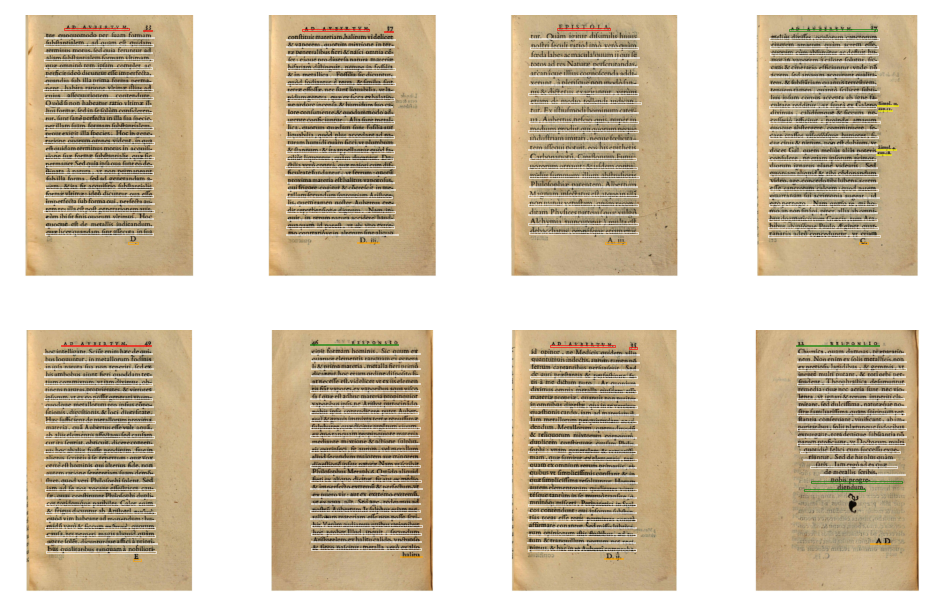

In [35]:
import os
import pickle
import numpy as np
import ipywidgets as widgets
import fitz  # PyMuPDF
from IPython.display import display
import matplotlib.pyplot as plt

dest_dir = "/srv/data/tome/tome-corpus/emlap_annotated_textblocks/"
try:
    os.mkdir(dest_dir)
except:
    pass

# Main loop through source directory
source_dir = "/srv/data/tome/tome-corpus/emlap_raw_2025-03-10/"
for dir in os.listdir(source_dir):
    filename = [f for f in os.listdir(os.path.join(source_dir, dir)) if ".pdf" in f][0]
    filepath = os.path.join(source_dir, dir, filename)
    doc = fitz.open(filepath)
    # Define a state to track input and re-execution
    should_continue = False  # Determines when to exit the loop
    while not should_continue:
        # Display the sample first
        print(f"Processing file: {filename}")
        samples_annots = test_doc_annotations(doc, params)  # Render the plot in the notebook
        # Prompt the user for input
        choice = menu_prompt()

        if choice == 1:
            # Apply and save the annotations; exit the loop
            apply_and_save_annotations(filename, doc, params, dest_dir)
            should_continue = True  # Break the loop and proceed to the next file

        elif choice == 2:
            # Rerun the annotations process with the same parameters
            print("Rerunning with the same parameters...")

        elif choice == 3:
            # Allow the user to input revised parameters
            params = input("Insert revised parameters: ")
            print("Parameters updated. Rerunning...")

In [26]:
import matplotlib
import matplotlib.pyplot as plt

# Set interactive mode and backend for plots
matplotlib.use('Qt5Agg')  # Or 'TkAgg', depending on your system
plt.ion()  # Turn on interactive mode in matplotlib

ImportError: Cannot load backend 'Qt5Agg' which requires the 'qt' interactive framework, as 'headless' is currently running

In [38]:
print(matplotlib.rcsetup.all_backends)


['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']


/tmp/ipykernel_1109854/157059035.py:1: MatplotlibDeprecationWarning: The all_backends attribute was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use ``matplotlib.backends.backend_registry.list_builtin()`` instead.
  print(matplotlib.rcsetup.all_backends)


In [39]:
matplotlib.use('TkAgg')  # Switch to TkAgg
import matplotlib.pyplot as plt

ImportError: Cannot load backend 'TkAgg' which requires the 'tk' interactive framework, as 'headless' is currently running


Processing file: DuChesne1575_Ad_Iacobi_Auberti_MDZ_Augsburg.pdf


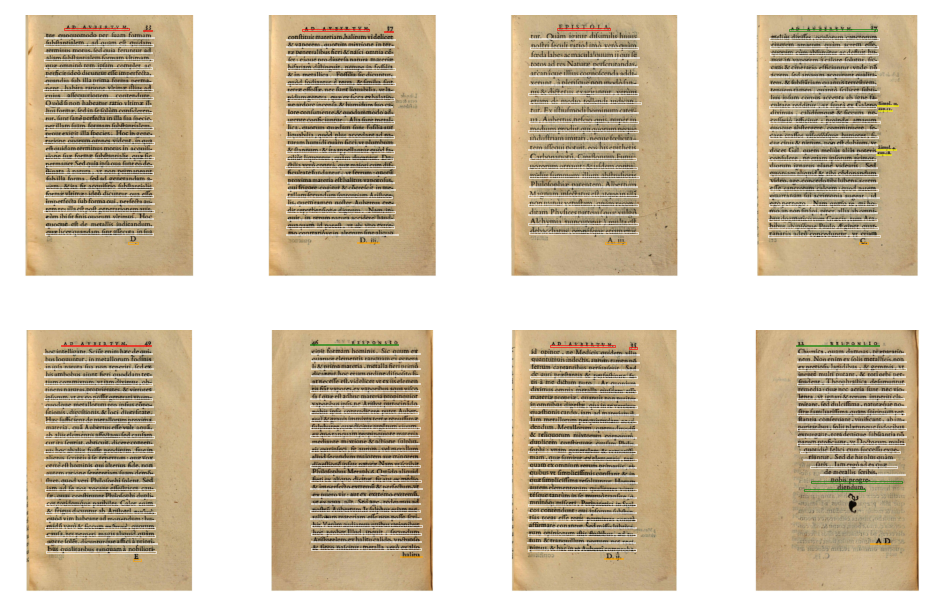

<Figure size 640x480 with 0 Axes>


Options:
 [1] Accept and Save
 [2] Another Sample (rerun test with the same parameters)
 [3] Revise Parameters and rerun


KeyboardInterrupt: Interrupted by user

In [33]:
import os

for dir in os.listdir(source_dir):
    filename = [f for f in os.listdir(os.path.join(source_dir, dir)) if ".pdf" in f][0]
    filepath = os.path.join(source_dir, dir, filename)
    doc = fitz.open(filepath)

    should_continue = False

    while not should_continue:
        # Step 1: Render and display the immediate output
        print(f"\nProcessing file: {filename}")
        print("===================================================")
        test_doc_annotations(doc, params)  # Render the plot or print the output
             # Force the plot to display immediately
        plt.draw()  # Update the plot in the notebook
        plt.pause(0.1)  # Short pause to ensure the plot is drawn

        # Step 2: Explicitly prompt the user WITH CLEAR INSTRUCTIONS
        print("\nOptions:")
        print(" [1] Accept and Save")
        print(" [2] Another Sample (rerun test with the same parameters)")
        print(" [3] Revise Parameters and rerun")

        choice = input("Select an action (1 - 3): ")
        print()  # Blank line for spacing after input

        # Step 3: Handle the user choice based on input
        if choice == "1":
            apply_and_save_annotations(filename, doc, params, dest_dir)
            print(f"\nAnnotations applied and saved for {filename}. Moving to next file.")
            should_continue = True  # Exit the loop and proceed

        elif choice == "2":
            print("Rerunning with the SAME parameters...\n")
            # Loop continues and `test_doc_annotations` will be re-executed

        elif choice == "3":
            params = input("Insert revised parameters: ")
            print(f"Parameters updated to: {params}. Rerunning...\n")
            # Loop continues; rerun happens automatically

        else:
            print("Invalid input. Please enter 1, 2, or 3.")


In [28]:

def menu_prompt():
    print("Options:")
    print(" [1] Accept and Save")
    print(" [2] Another Sample")
    print(" [3] Revise Parameters")

    while True:
        choice = input("Select an action (1 - 3): ")
        if choice in ["1", "2", "3"]:
            return int(choice)
        else:
            print("Invalid input, please enter 1, 2, or 3.")


# Usage
choice = menu_prompt()

if choice == 1:
    print("You selected: Accept and Save")
elif choice == 2:
    print("You selected: Another Sample")
elif choice == 3:
    print("You selected: Revise Parameters")

Options:
 [1] Accept and Save
 [2] Another Sample
 [3] Revise Parameters


KeyboardInterrupt: Interrupted by user

In [ ]:
flattext = ""
for p_textblocks in pages_textblocks_annotated:
    for textblock in p_textblocks:
        if textblock[5] == "text":
            flattext += textblock[4]

In [ ]:
print(flattext)

In [31]:
topdir = "/srv/data/tome/tome-corpus/emlap_raw_2025-04-08/"
filepaths1 = [os.path.join(topdir, dir, [f for f in os.listdir(os.path.join(topdir, dir)) if ".pdf" in f][0]) for dir in os.listdir(topdir) if "." not in dir]

topdir = "/srv/data/tome/tome-corpus/emlap_raw_2025-09/"
filepaths2 = [os.path.join(topdir, dir, [f for f in os.listdir(os.path.join(topdir, dir)) if ".pdf" in f][0]) for dir in os.listdir(topdir) if "." not in dir]

In [32]:
filepaths2

['/srv/data/tome/tome-corpus/emlap_raw_2025-09/3830200/Greverus1599_Secretum_MDZ_MBS.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/2683184/Hoghelande1595_De_lapidis_physici_conditionibus_MDZ_MBS.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/1681867/Gessner1569_Thesaurus_Euonymi_Philiatri_Liber_Secundus_MDZ_MBS.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/1681622/Gessner1552_Thesaurus_Euonymi_Philiatri_ER_ZZ.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/1654560/De_alchemia1541_MDZ_MBS.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/4964476/Pantheus1519_Commentarium_Transmutationis_Metallicae_MDZ.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/1638362/Savonarola1532_De_arte_conficiendi_aquam_vitae_ONB.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/1698708/Toxites1567_Spongia_stibii_MDZ_MBS.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/2257959/Dorn1581_Fasciculus_Paracelsicae_MDZ_MBS.pdf',
 '/srv/data/tome/tome-corpus/emlap_raw_2025-09/1

In [34]:
os.listdir("/srv/data/tome/tome-corpus/emlap_raw_2025-09/2683184/Hoghelande1595_De_lapidis_physici_conditionibus_MDZ_MBS/")

['0124_p124.jpg',
 '0019_p019.jpg',
 '0262_p262.jpg',
 '0174_p174.jpg',
 '0187_p187.jpg',
 '0032_p032.jpg',
 '0226_p226.jpg',
 '0182_p182.jpg',
 '0156_p156.jpg',
 '0081_p081.jpg',
 '0069_p069.jpg',
 '0277_p277.jpg',
 '0219_p219.jpg',
 '0146_p146.jpg',
 '0016_p016.jpg',
 '0268_p268.jpg',
 '0071_p071.jpg',
 '0086_p086.jpg',
 '0137_p137.jpg',
 '0165_p165.jpg',
 '0118_p118.jpg',
 '0078_p078.jpg',
 '0253_p253.jpg',
 '0005_p005.jpg',
 '0224_p224.jpg',
 '0070_p070.jpg',
 '0027_p027.jpg',
 '0240_p240.jpg',
 '0288_p288.jpg',
 '0006_p006.jpg',
 '0178_p178.jpg',
 '0153_p153.jpg',
 '0017_p017.jpg',
 '0122_p122.jpg',
 '0111_p111.jpg',
 '0189_p189.jpg',
 '0148_p148.jpg',
 '0112_p112.jpg',
 '0130_p130.jpg',
 '0012_p012.jpg',
 '0084_p084.jpg',
 '0058_p058.jpg',
 '0280_p280.jpg',
 '0031_p031.jpg',
 '0085_p085.jpg',
 '0001_p001.jpg',
 '0218_p218.jpg',
 '0062_p062.jpg',
 '0186_p186.jpg',
 '0184_p184.jpg',
 '0022_p022.jpg',
 '0256_p256.jpg',
 '0021_p021.jpg',
 '0282_p282.jpg',
 '0015_p015.jpg',
 '0102_p10